## ***Distributed Sales Data Analysis (PySpark)***

**Objectives**
- Load a large CSV dataset
- Clean missing values
- Compute total, top-selling store, and average sales
- Visualize results
- Compare Spark with normal Python (pandas)


## ***Spark session and data load***
Create a local Spark session and read the CSV into a DataFrame for analysis.

In [65]:
from pyspark.sql import SparkSession

# Create Spark session with explicit driver bind address for local runs.
spark = SparkSession.builder \
    .appName("Sales Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

# Reduce Spark log noise.
spark.sparkContext.setLogLevel("WARN")

# Load CSV file
df = spark.read.csv("grocerySale.csv", header=True, inferSchema=True)

## ***Preview the raw data***
Display a few rows to confirm the file loaded correctly.

In [66]:
# Show dataset
df.show(5)

+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+-----------+-----------+------+
|Item Fat Content|Item Identifier|           Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|      Outlet Type|Item Visibility|Item Weight|Total Sales|Rating|
+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+-----------+-----------+------+
|         Regular|          FDX32|Fruits and Vegeta...|                     2012|           OUT049|              Tier 1|     Medium|Supermarket Type1|      0.1000135|       15.1|   145.4786|   5.0|
|         Low Fat|          NCB42|  Health and Hygiene|                     2022|           OUT018|              Tier 3|     Medium|Supermarket Type2|    0.008596051|       11.8|   115.3492|   5.0|
|         

## ***Inspect the schema***
Check inferred column types to guide cleaning and analysis.

In [67]:
df.printSchema()

root
 |-- Item Fat Content: string (nullable = true)
 |-- Item Identifier: string (nullable = true)
 |-- Item Type: string (nullable = true)
 |-- Outlet Establishment Year: integer (nullable = true)
 |-- Outlet Identifier: string (nullable = true)
 |-- Outlet Location Type: string (nullable = true)
 |-- Outlet Size: string (nullable = true)
 |-- Outlet Type: string (nullable = true)
 |-- Item Visibility: double (nullable = true)
 |-- Item Weight: double (nullable = true)
 |-- Total Sales: double (nullable = true)
 |-- Rating: double (nullable = true)



## ***Basic dataset size***
Count rows and columns to understand scale.

In [68]:
print("Rows:", df.count())
print("Columns:", len(df.columns))

Rows: 8523
Columns: 12


## ***Check missing values***
Count null or NaN values per column before cleaning.

In [69]:
from pyspark.sql.functions import col, isnan, when, count

df.select([
    count(
        when(
            col(c).isNull() | isnan(c),
            c
        )
    ).alias(c)
    for c in df.columns
]).show()

+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+
|Item Fat Content|Item Identifier|Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|Outlet Type|Item Visibility|Item Weight|Total Sales|Rating|
+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+
|               0|              0|        0|                        0|                0|                   0|          0|          0|              0|       1463|          0|     0|
+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+



## ***Compute mean item weight***
Use the column mean to impute missing item weights.

In [70]:
from pyspark.sql.functions import mean

mean_weight = df.select(
    mean("Item Weight")
).collect()[0][0]

print(mean_weight)

12.857645184136176


## ***Impute missing item weight***
Fill null `Item Weight` values using the computed mean.

In [71]:
df = df.fillna({
    "Item Weight": mean_weight
})

## ***Recheck missing values***
Validate that key nulls were addressed.

In [72]:
from pyspark.sql.functions import col, isnan, when, count

df.select([
    count(
        when(
            col(c).isNull() | isnan(c),
            c
        )
    ).alias(c)
    for c in df.columns
]).show()

+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+
|Item Fat Content|Item Identifier|Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|Outlet Type|Item Visibility|Item Weight|Total Sales|Rating|
+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+
|               0|              0|        0|                        0|                0|                   0|          0|          0|              0|          0|          0|     0|
+----------------+---------------+---------+-------------------------+-----------------+--------------------+-----------+-----------+---------------+-----------+-----------+------+



## ***Drop rows with nulls***
Create a cleaned DataFrame by removing incomplete rows.

In [73]:
# Remove rows with missing values
clean_df = df.dropna()

clean_df.show()

+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+------------------+-----------+------+
|Item Fat Content|Item Identifier|           Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|      Outlet Type|Item Visibility|       Item Weight|Total Sales|Rating|
+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+------------------+-----------+------+
|         Regular|          FDX32|Fruits and Vegeta...|                     2012|           OUT049|              Tier 1|     Medium|Supermarket Type1|      0.1000135|              15.1|   145.4786|   5.0|
|         Low Fat|          NCB42|  Health and Hygiene|                     2022|           OUT018|              Tier 3|     Medium|Supermarket Type2|    0.008596051|              

## ***Alternative fill strategy***
Fill specific columns with defaults for an alternate cleaned view.

In [74]:
filled_df = df.fillna({
    "Item Weight": 0,
    "Outlet Size": "Unknown"
})

## ***Check for duplicates***
Count duplicate rows to avoid double counting in metrics.

In [75]:
print("Duplicate Rows:",
      df.count() - df.dropDuplicates().count())

Duplicate Rows: 0


## ***Remove duplicates***
Keep only unique rows for analysis.

In [76]:
df = df.dropDuplicates()

## ***Summary statistics***
Quick overview of numeric columns after cleaning.

In [77]:
df.describe().show()

+-------+----------------+---------------+-------------+-------------------------+-----------------+--------------------+-----------+-----------------+-------------------+------------------+------------------+------------------+
|summary|Item Fat Content|Item Identifier|    Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|      Outlet Type|    Item Visibility|       Item Weight|       Total Sales|            Rating|
+-------+----------------+---------------+-------------+-------------------------+-----------------+--------------------+-----------+-----------------+-------------------+------------------+------------------+------------------+
|  count|            8523|           8523|         8523|                     8523|             8523|                8523|       8523|             8523|               8523|              8523|              8523|              8523|
|   mean|            NULL|           NULL|         NULL|       2010.8318667135984|  

## ***Check categorical values***
Review distinct `Item Fat Content` values before normalization.

In [78]:
df.select("Item Fat Content").distinct().show()

+----------------+
|Item Fat Content|
+----------------+
|         low fat|
|         Low Fat|
|              LF|
|         Regular|
|             reg|
+----------------+



## ***Normalize fat content labels***
Standardize inconsistent values for consistent analysis.

In [79]:
from pyspark.sql.functions import col, when

df = df.withColumn(
    "Item Fat Content",
    
    when(
        col("Item Fat Content").isin(
            "LF", "low fat", "Low Fat"
        ),
        "Low Fat"
    )
    
    .when(
        col("Item Fat Content").isin(
            "reg", "Regular"
        ),
        "Regular"
    )
    
    .otherwise(col("Item Fat Content"))
)

## ***Sales distribution summary***
Check descriptive stats for `Total Sales`.

In [80]:
df.select("Total Sales").describe().show()

+-------+------------------+
|summary|       Total Sales|
+-------+------------------+
|  count|              8523|
|   mean|140.99278197817716|
| stddev|  62.2750665121905|
|    min|             31.29|
|    max|          266.8884|
+-------+------------------+



## ***Total sales sum***
Compute overall sales volume.

In [81]:
from pyspark.sql.functions import sum

df.select(
    sum("Total Sales")
).show()

+-----------------+
| sum(Total Sales)|
+-----------------+
|1201681.480800004|
+-----------------+



## ***Average sales***
Compute the mean of `Total Sales`.

In [82]:
from pyspark.sql.functions import avg

df.select(
    avg("Total Sales")
).show()

+------------------+
|  avg(Total Sales)|
+------------------+
|140.99278197817716|
+------------------+



## ***Top-selling outlet***
Aggregate sales by outlet and sort descending.

In [83]:
from pyspark.sql.functions import desc

top_store = df.groupBy(
    "Outlet Identifier"
).sum("Total Sales") \
 .orderBy(
    desc("sum(Total Sales)")
 )

top_store.show()

+-----------------+------------------+
|Outlet Identifier|  sum(Total Sales)|
+-----------------+------------------+
|           OUT035|133103.90699999992|
|           OUT046|132113.36980000001|
|           OUT013|131809.01559999998|
|           OUT018|131477.77239999996|
|           OUT045| 130942.7782000001|
|           OUT027|130714.67459999995|
|           OUT049|130476.85980000003|
|           OUT017|129103.95640000007|
|           OUT010| 78131.56460000006|
|           OUT019| 73807.58239999998|
+-----------------+------------------+



## ***Outlet age feature***
Derive outlet age from establishment year.

In [84]:
from pyspark.sql.functions import lit

current_year = 2026

df = df.withColumn(
    "Outlet Age",
    lit(current_year) - col("Outlet Establishment Year")
)

df.select(
    "Outlet Establishment Year",
    "Outlet Age"
).show(10)

+-------------------------+----------+
|Outlet Establishment Year|Outlet Age|
+-------------------------+----------+
|                     2015|        11|
|                     2017|         9|
|                     1998|        28|
|                     2015|        11|
|                     2020|         6|
|                     2011|        15|
|                     2022|         4|
|                     1998|        28|
|                     2012|        14|
|                     2012|        14|
+-------------------------+----------+
only showing top 10 rows



## ***Final sample preview***
Show a few rows with the new features applied.

In [85]:
df.show(5)

+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+------------------+-----------+------+----------+
|Item Fat Content|Item Identifier|           Item Type|Outlet Establishment Year|Outlet Identifier|Outlet Location Type|Outlet Size|      Outlet Type|Item Visibility|       Item Weight|Total Sales|Rating|Outlet Age|
+----------------+---------------+--------------------+-------------------------+-----------------+--------------------+-----------+-----------------+---------------+------------------+-----------+------+----------+
|         Low Fat|          FDN32|Fruits and Vegeta...|                     2015|           OUT045|              Tier 2|     Medium|Supermarket Type1|    0.015591925|              17.5|   184.8266|   5.0|        11|
|         Low Fat|          FDH10|         Snack Foods|                     2017|           OUT035|              Tier 2|      Small|Supe

In [86]:
df.groupBy("Outlet Type") \
  .avg("Total Sales") \
  .show()

+-----------------+------------------+
|      Outlet Type|  avg(Total Sales)|
+-----------------+------------------+
|Supermarket Type3|139.80179101604273|
|    Grocery Store|140.29468790397036|
|Supermarket Type2| 141.6786340517241|
|Supermarket Type1| 141.2138939931866|
+-----------------+------------------+



## Visualizations

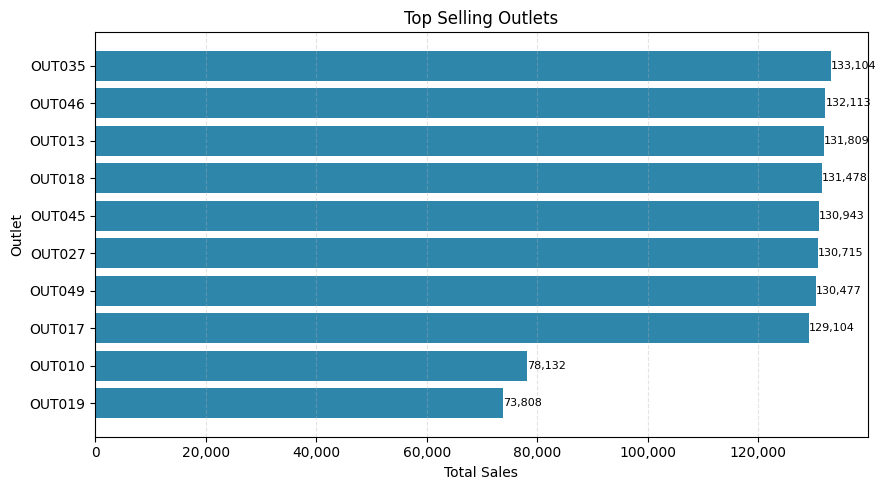

In [87]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

data = top_store.toPandas().head(10)
data = data.sort_values("sum(Total Sales)")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    data["Outlet Identifier"],
    data["sum(Total Sales)"],
    color="#2E86AB"
 )

ax.set_title("Top Selling Outlets")
ax.set_xlabel("Total Sales")
ax.set_ylabel("Outlet")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="x", linestyle="--", alpha=0.35)

for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height() / 2, f"{width:,.0f}",
            va="center", ha="left", fontsize=8)

plt.tight_layout()
plt.show()

***Sales Distribution Histogram***

Shows how sales values are distributed.

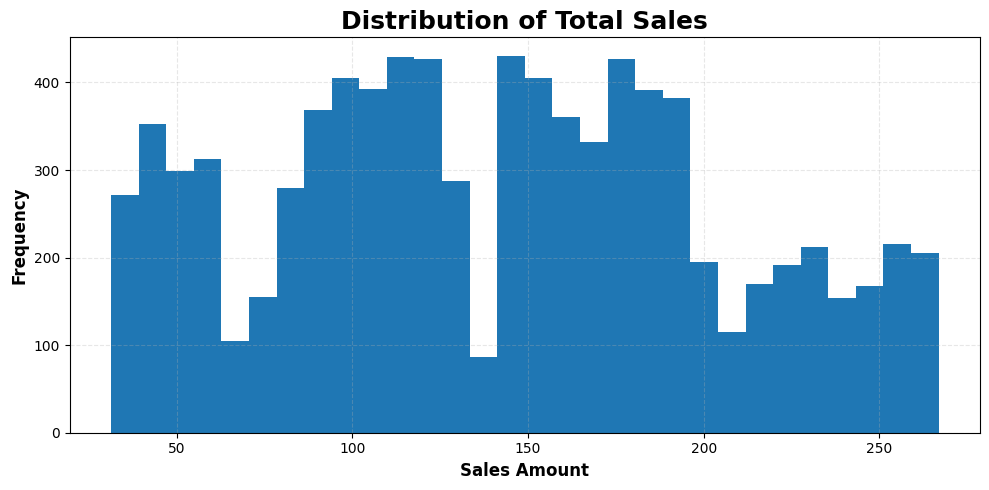

In [88]:
sales_data = df.select("Total Sales").toPandas()
plt.figure(figsize=(10, 5))

plt.hist(sales_data["Total Sales"],bins=30)
plt.title("Distribution of Total Sales", fontsize=18, fontweight="bold")
plt.xlabel("Sales Amount", fontsize=12, fontweight="bold")
plt.ylabel("Frequency", fontsize=12, fontweight="bold")

plt.grid(linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

***Sales by Item Type***

Best product categories by sales.

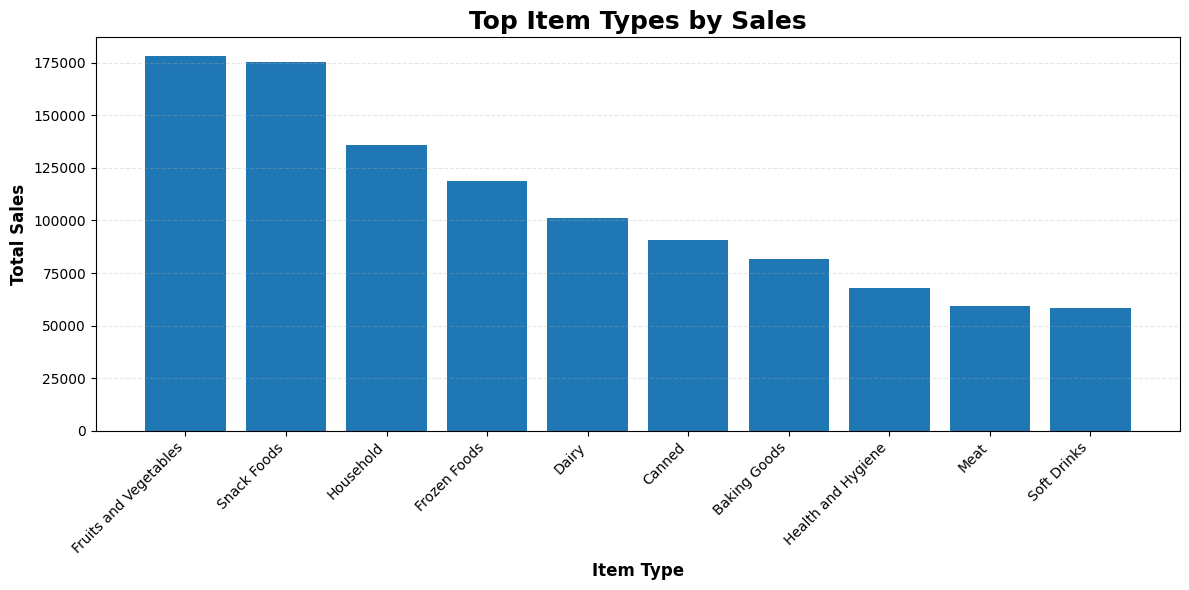

In [89]:
sales_type = df.groupBy("Item Type").sum("Total Sales")
sales_type_pd = sales_type.toPandas()
sales_type_pd = sales_type_pd.sort_values("sum(Total Sales)", ascending=False).head(10)

plt.figure(figsize=(12, 6))

plt.bar(sales_type_pd["Item Type"], sales_type_pd["sum(Total Sales)"])
plt.xticks(rotation=45, ha="right")
plt.title("Top Item Types by Sales", fontsize=18, fontweight="bold")
plt.xlabel("Item Type", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

***Average Sales by Outlet Type***

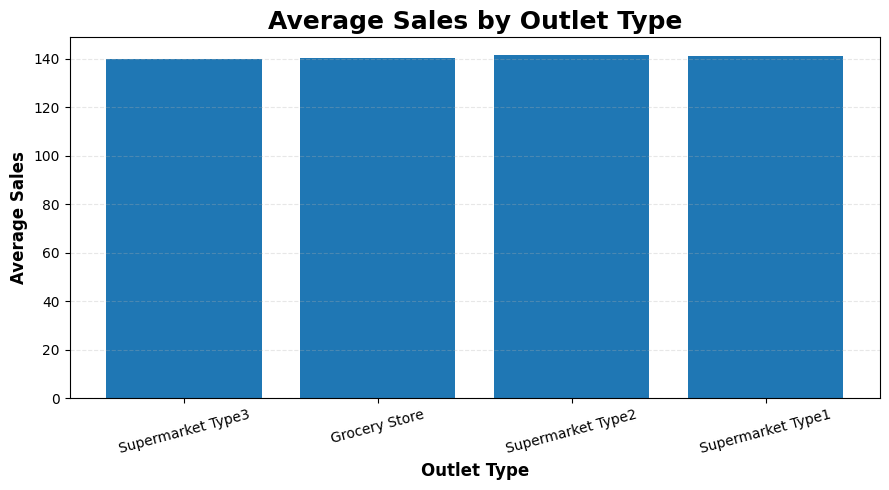

In [90]:
avg_sales = df.groupBy("Outlet Type").avg("Total Sales")
avg_sales_pd = avg_sales.toPandas()

plt.figure(figsize=(9, 5))

plt.bar(avg_sales_pd["Outlet Type"], avg_sales_pd["avg(Total Sales)"])
plt.title("Average Sales by Outlet Type", fontsize=18, fontweight="bold")
plt.xlabel("Outlet Type",fontsize=12, fontweight="bold")
plt.ylabel("Average Sales",fontsize=12,fontweight="bold")
plt.xticks(rotation=15)

plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

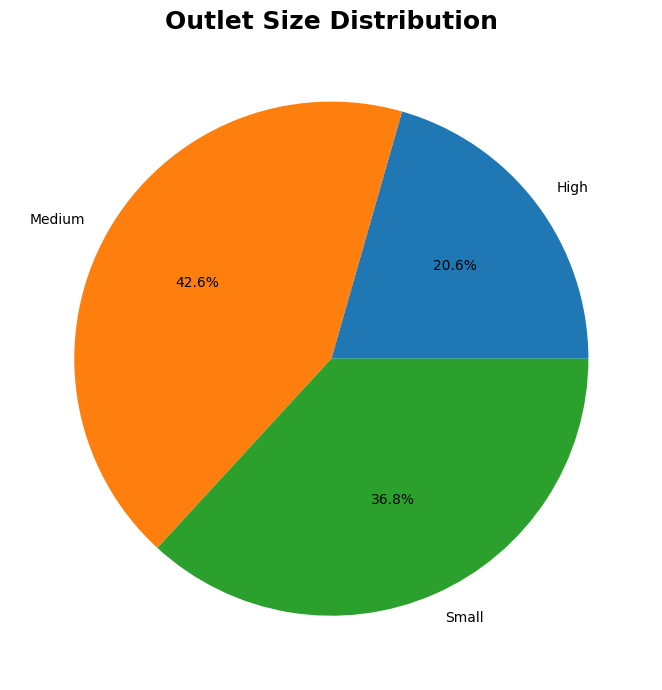

In [91]:
size_data = df.groupBy(
    "Outlet Size"
).count()

size_pd = size_data.toPandas()

plt.figure(figsize=(7, 7))

plt.pie(
    size_pd["count"],
    labels=size_pd["Outlet Size"],
    autopct="%1.1f%%"
)

plt.title(
    "Outlet Size Distribution",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

***Sales Trend by Establishment Year***

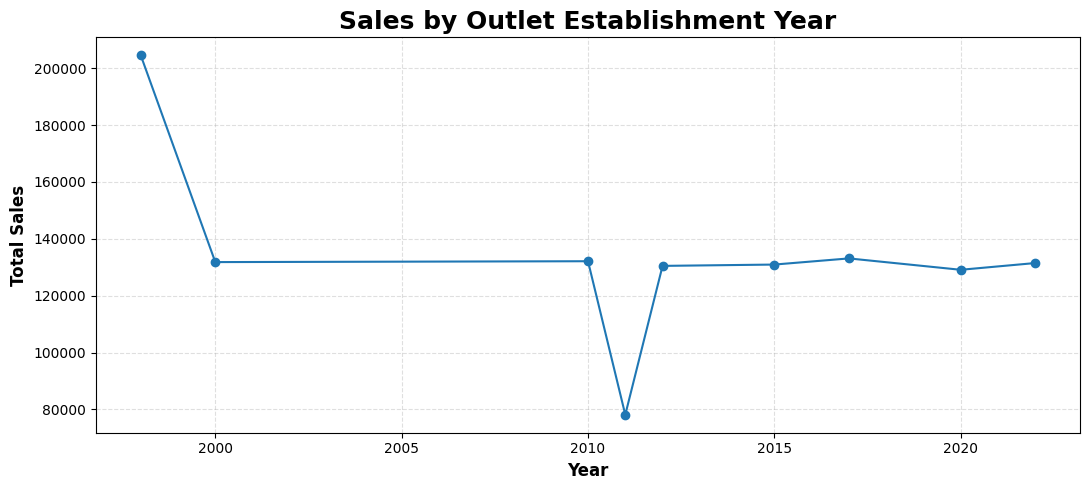

In [92]:
year_sales = df.groupBy("Outlet Establishment Year").sum("Total Sales")

year_pd = year_sales.toPandas()
year_pd = year_pd.sort_values("Outlet Establishment Year")
plt.figure(figsize=(11, 5))

plt.plot(year_pd["Outlet Establishment Year"], year_pd["sum(Total Sales)"], marker="o")
plt.title("Sales by Outlet Establishment Year", fontsize=18, fontweight="bold")
plt.xlabel("Year", fontsize=12, fontweight="bold")
plt.ylabel("Total Sales", fontsize=12, fontweight="bold")

plt.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

## ***Normal Python Processing Using Pandas***

## ***Load Dataset***

In [93]:
import pandas as pd

# Load CSV file

df = pd.read_csv("grocerySale.csv")

In [94]:
# Show first rows
df

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Total Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0


### ***Check Missing Values***

In [95]:
print(df.isnull().sum())

Item Fat Content                0
Item Identifier                 0
Item Type                       0
Outlet Establishment Year       0
Outlet Identifier               0
Outlet Location Type            0
Outlet Size                     0
Outlet Type                     0
Item Visibility                 0
Item Weight                  1463
Total Sales                     0
Rating                          0
dtype: int64


### ***Fill Missing Values***

In [96]:
# Fill missing Item Weight with mean
df["Item Weight"] = df["Item Weight"].fillna(
    df["Item Weight"].mean()
)

### ***Standardize Categories***

In [97]:
df["Item Fat Content"] = df[
    "Item Fat Content"
].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

### ***Compute Total Sales***

In [98]:
total_sales = df["Total Sales"].sum()

print("Total Sales:", total_sales)

Total Sales: 1201681.4808


### ***Compute Average Sales***

In [99]:
average_sales = df["Total Sales"].mean()

print("Average Sales:", average_sales)

Average Sales: 140.9927819781767


### ***Top-Selling Outlet***

In [100]:
top_store = df.groupby(
    "Outlet Identifier"
)["Total Sales"].sum()

top_store = top_store.sort_values(
    ascending=False
)

print(top_store.head(10))

Outlet Identifier
OUT035    133103.9070
OUT046    132113.3698
OUT013    131809.0156
OUT018    131477.7724
OUT045    130942.7782
OUT027    130714.6746
OUT049    130476.8598
OUT017    129103.9564
OUT010     78131.5646
OUT019     73807.5824
Name: Total Sales, dtype: float64


### ***Visualization Using Matplotlib***

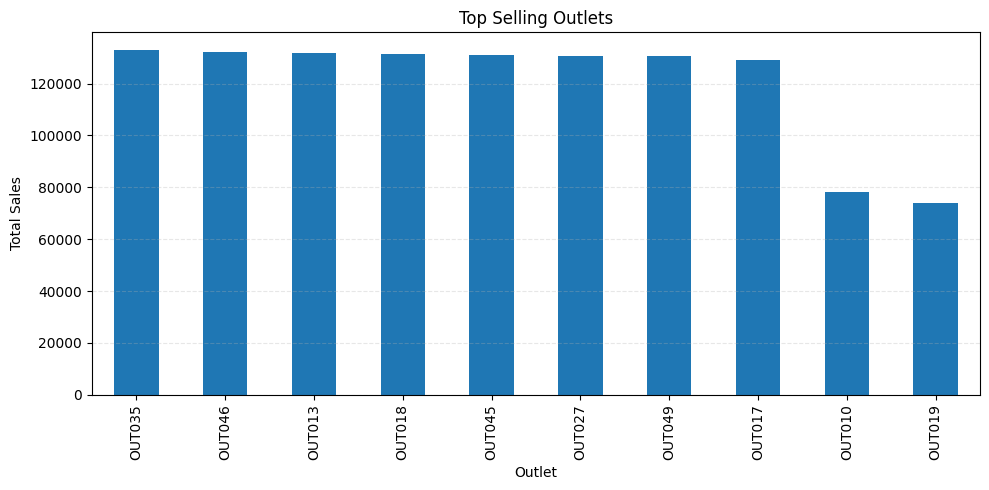

In [107]:
import matplotlib.pyplot as plt

top10 = top_store.head(10)

plt.figure(figsize=(10, 5))

top10.plot(kind="bar")

plt.title("Top Selling Outlets")
plt.xlabel("Outlet")
plt.ylabel("Total Sales")

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

## ***Processing Time Comparison***

We can measure execution time.

PySpark Timing

In [106]:
import time

Spark_df = spark.read.csv("grocerySale.csv", header=True, inferSchema=True)

start = time.time()

Spark_df.groupBy("Outlet Identifier").sum("Total Sales").show()

end = time.time()

print("PySpark Time:", end - start)

+-----------------+------------------+
|Outlet Identifier|  sum(Total Sales)|
+-----------------+------------------+
|           OUT027|130714.67460000006|
|           OUT046|132113.36980000007|
|           OUT013|131809.01560000007|
|           OUT019| 73807.58239999998|
|           OUT018|131477.77239999996|
|           OUT010| 78131.56459999997|
|           OUT045|130942.77819999999|
|           OUT035| 133103.9069999999|
|           OUT017|129103.95639999988|
|           OUT049|130476.85979999998|
+-----------------+------------------+

PySpark Time: 0.07784175872802734


Normal Python Timing

In [110]:
import time

Python_df = pd.read_csv("grocerySale.csv")

start = time.time()

Python_df.groupby("Outlet Identifier")["Total Sales"].sum()

end = time.time()

print("Pandas Time:", end - start)

Pandas Time: 0.00464320182800293


## Key differences: PySpark vs pandas 

**Normal Python (pandas)**
- Runs on a single machine, mostly sequential.
- Great for small datasets and quick exploration.
- Limited by one machine's memory and CPU.

**PySpark**
- Distributes work across multiple workers in parallel.
- Best for large datasets and scalable pipelines.
- More setup and overhead for small data.

**Distributed processing (Spark)**
- Worker 1: rows 1-3000
- Worker 2: rows 3001-6000
- Worker 3: rows 6001-9000

**Single-machine processing (pandas)**
- One CPU processes all rows in order; slows down as data grows.

**Quick comparison**

| Feature | Pandas | PySpark |
|---|---|---|
| Processing | Sequential | Parallel |
| Small data | Fast | Overhead |
| Big data | Slow | Fast |
| Scalability | Limited | High |
| Memory | Single machine | Distributed |
| Fault tolerance | Low | High |

**Which to choose?**
- Small CSVs or learning: pandas.
- Big data or production pipelines: PySpark.

**Real-world usage**
- Common in large-scale analytics at Netflix, Amazon, Uber, and others.

**Bottom line**
PySpark becomes more powerful as data grows because it splits work across multiple machines.